# LangGraph
1. Define state object
2. Start the graph builder
3. Create node
4. create edges
5. Compile the graph

### 1. Define the state object
Annotated will be used to attach the metadata (a reducer function). It is used by Langgraph as a context for updating the field.

In [ ]:
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages

class State(BaseModel):
    messages: Annotated[list, add_messages]

### 2. Start the graph builder

In [3]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)

### 3. Create node
A node can be any python function that takes the previous state and returns the new updated state.

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_openai import ChatOpenAI

def llm_node(old_state: State) -> State:
    llm = ChatOpenAI(model_name="gpt-4o-mini")
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state

graph_builder.add_node("llm", llm_node)

### 4. Create edges

In [6]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)

### 5. Compile the graph

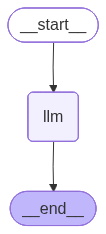

In [7]:
from IPython.display import display, Image

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### Now, Run

In [8]:
user_input = "Explain the theory of relativity in simple terms."
initial_state = State(messages=[{"role": "user", "content": user_input}])
result = graph.invoke(initial_state)

print(result)
print(result["messages"][-1].content)

{'messages': [HumanMessage(content='Explain the theory of relativity in simple terms.', additional_kwargs={}, response_metadata={}, id='a31a756d-74ba-441b-a25f-7a3e884ef376'), AIMessage(content="The theory of relativity, developed by Albert Einstein, comprises two main parts: special relativity and general relativity. Here's a simple breakdown of each:\n\n### Special Relativity\n1. **Basic Idea**: This theory focuses on the behavior of objects moving at constant speeds, especially those moving close to the speed of light. \n2. **Key Concepts**:\n   - **Speed of Light**: Light travels at a constant speed (about 299,792 kilometers per second) in a vacuum, regardless of how fast you’re moving. \n   - **Time Dilation**: Time can pass at different rates depending on how fast an object is moving. For example, if you traveled in a spaceship close to the speed of light, you would age more slowly compared to someone on Earth.\n   - **Length Contraction**: Objects moving close to the speed of li